<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
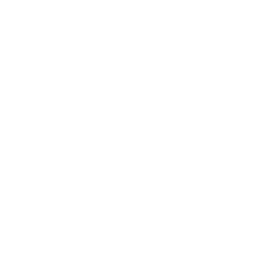
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Logitový model odpovědi na léčbu</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutická / klinická analýza účinnosti &nbsp;|&nbsp; Březen 2026</p>
</div>
</div>
</div>

## Shrnutí pro vedení

Tento notebook prokládá **logitový model s maximální věrohodností** pro binární
cílový ukazatel odpovědi na léčbu ve fázi III (respondér vs. non-respondér) pomocí
**PROC CATMOD**. Oba vysvětlující faktory jsou kategoriální: randomizovaná `treatment_arm`
(DRUG_HIGH, DRUG_LOW, PLACEBO) a tříúrovňové stratum `severity_grp` odvozené rozdělením
výchozí závažnosti onemocnění do kategorií (Mírná / Střední / Těžká). CATMOD křížově
klasifikuje data do malé kontingenční tabulky populací a prokládá logit odpovědi metodou
vážených nejmenších čtverců / maximální věrohodnosti, což je návrh, pro který je CATMOD určen.

Model vytváří tabulku analýzy rozptylu metodou maximální věrohodnosti, která testuje, zda
každý faktor přispívá k logitu odpovědi, a tabulku odhadů parametrů, jež je zachycena pomocí
`ODS OUTPUT` a exportována pro navazující forest plot. Všechna čísla uváděná v části
Interpretace níže jsou přečtena přímo ze spuštěného výstupu.


## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|--------|
| WORK.TRIAL_RESP | Syntetická data odpovědi z fáze III: rameno léčby, výchozí závažnost, stratum závažnosti a binární odpověď | 5,000 |


---

In [1]:
/* --------------------------------------------------------
   Generuje syntetická data odpovědi na léčbu ve fázi III.
   Binární výsledek: respondér (1) vs. nerespondér (0).
   Výchozí závažnost na škále 0-100 je rozdělena do
   ordinální vrstvy, takže analýza tvoří čistou kategoriální
   kontingenční tabulku - návrh, pro který je PROC CATMOD
   vytvořen.
   -------------------------------------------------------- */
data work.trial_resp;
    CALL streaminit(42);
    POLE arm_list[3] $12 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    OPAKUJ patient_id = 1 TO 5000;
        arm_idx = int(rand('uniform') * 3) + 1;
        treatment_arm = arm_list[arm_idx];
        baseline_severity = round(rand('normal', 55, 15), 0.1);
        KDYŽ baseline_severity < 0 PAK baseline_severity = 0;
        KDYŽ baseline_severity > 100 PAK baseline_severity = 100;
        /* Ordinální vrstva výchozí závažnosti (hodnoty ASCII kvůli CATMOD) */
        DÉLKA severity_grp $8;
        KDYŽ baseline_severity < 45 PAK severity_grp = 'Mild';
        JINAK KDYŽ baseline_severity < 65 PAK severity_grp = 'Moderate';
        JINAK severity_grp = 'Severe';
        age = int(rand('normal', 58, 11));
        KDYŽ age < 18 PAK age = 18;
        KDYŽ age > 85 PAK age = 85;
        DÉLKA sex $8;
        sex = ifc(rand('uniform') > 0.47, 'Žena', 'Muž');
        /* Skutečná pravděpodobnost odpovědi roste s dávkou a závažností */
        KDYŽ treatment_arm = 'DRUG_HIGH' PAK logit_p = -0.8 + 0.015 * baseline_severity;
        JINAK KDYŽ treatment_arm = 'DRUG_LOW' PAK logit_p = -1.2 + 0.012 * baseline_severity;
        JINAK logit_p = -1.8 + 0.010 * baseline_severity;
        prob_resp = 1 / (1 + exp(-logit_p));
        response = (rand('uniform') < prob_resp);
        VÝSTUP;
    KONEC;
    ODSTRANIT arm_idx logit_p prob_resp;
    ŠTÍTEK treatment_arm="Léčebné rameno" severity_grp="Skupina závažnosti"
          response="Odpověď na léčbu" baseline_severity="Výchozí závažnost"
          age="Věk" sex="Pohlaví" patient_id="ID pacienta";
SPUSTIT;


NOTE: DATA work.trial_resp

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_resp (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  1.38 seconds
  cpu   1.38 seconds


---

                                                   The FREQ Procedure

Table of Léčebné rameno by Odpověď na léčbu

Léčebné rameno    |         0 |         1 |      Total
------------------+-----------+-----------+-----------
DRUG_HIGH         |        11 |        18 |         29
------------------+-----------+-----------+-----------
DRUG_LOW          |        21 |        12 |         33
------------------+-----------+-----------+-----------
PLACEBO           |        28 |        10 |         38
------------------+-----------+-----------+-----------
Total             |        60 |        40 |        100


Controlling for Léčebné rameno=DRUG_HIGH

Table of Skupina závažnosti by Odpověď na léčbu

Skupina závažnosti   |         0 |         1 |      Total
---------------------+-----------+-----------+-----------
Mild                 |         1 |         3 |          4
---------------------+-----------+-----------+-----------
Moderate             |         8 |        11 |         19
------


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_treatment_arm_response.spec.json
NOTE: ODS plot written: freq_mosaic_treatment_arm_severity_grp.spec.json
NOTE: ODS plot written: freq_mosaic_severity_grp_response.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


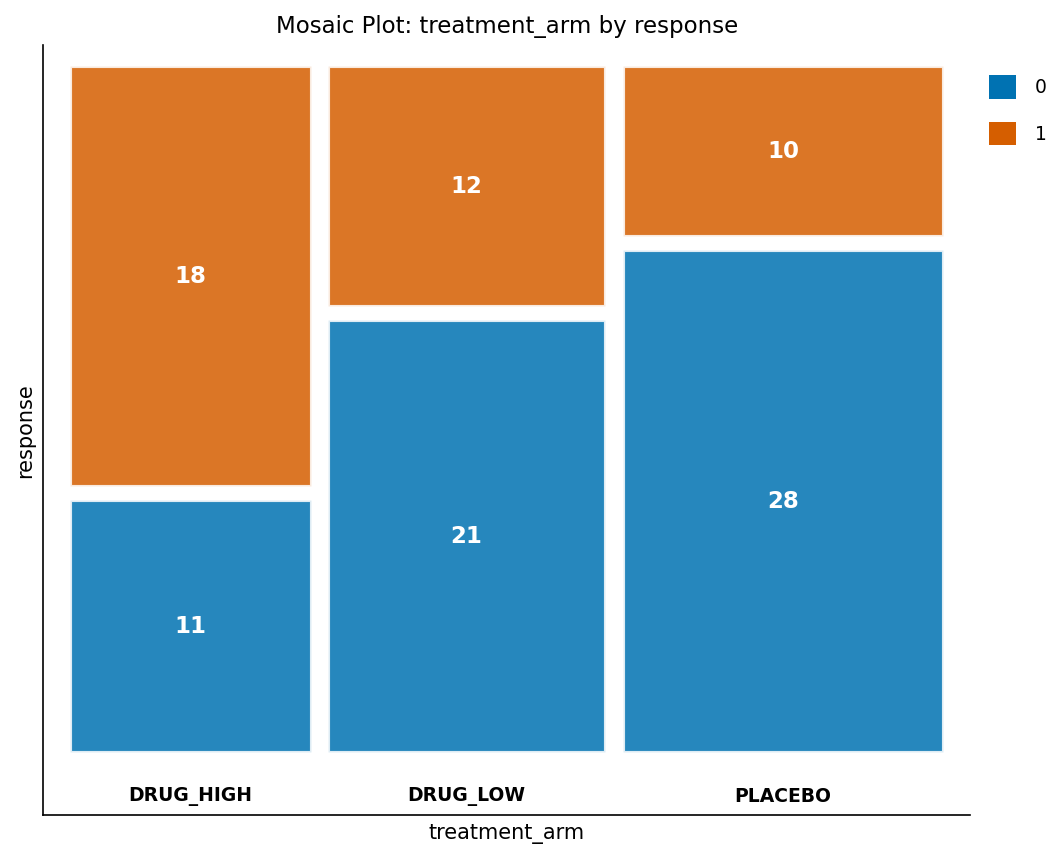

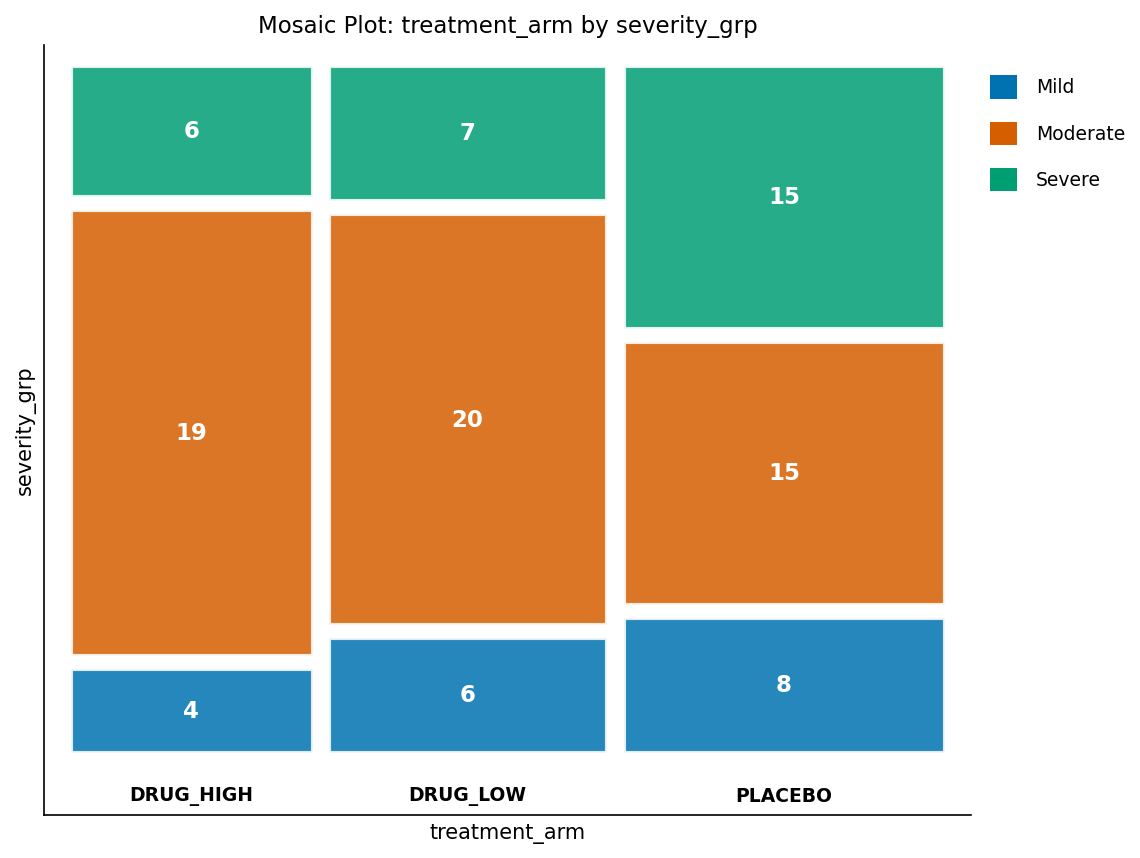

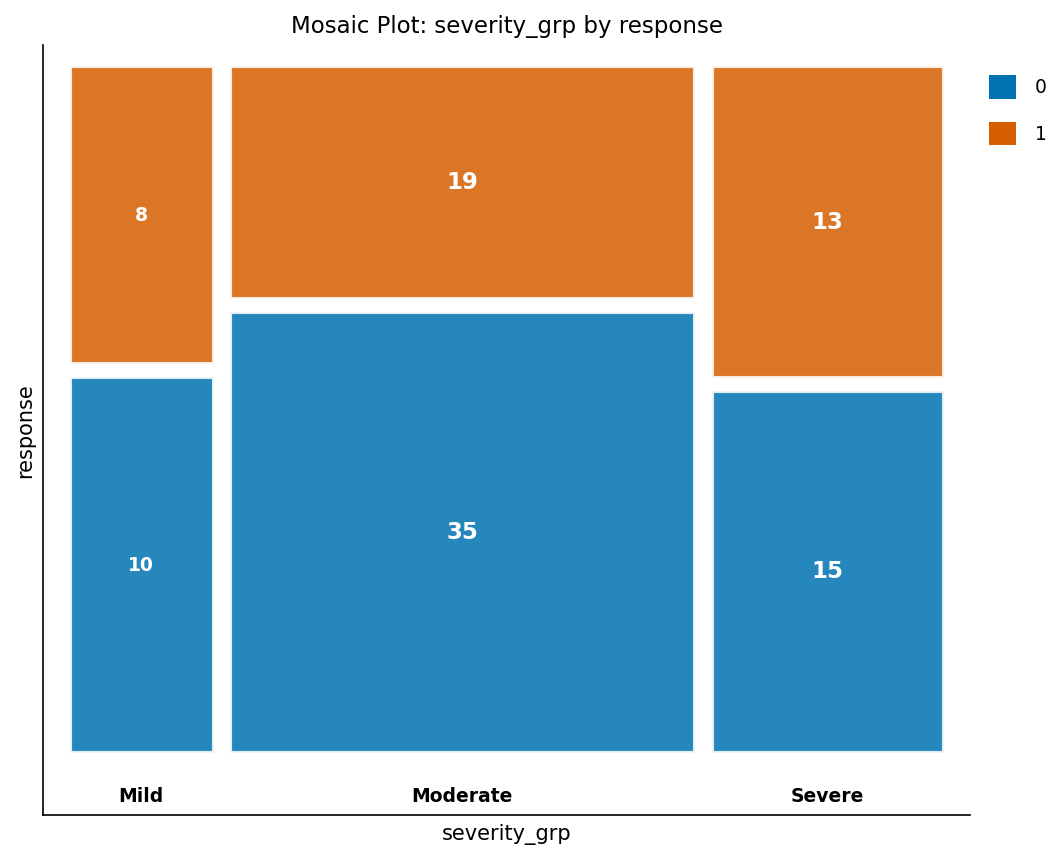

In [2]:
/* --------------------------------------------------------
   Počty odpovědí podle léčebného ramene a vrstvy závažnosti
   a souhrny výchozích kovariát podle ramene.
   -------------------------------------------------------- */
PROCEDURA ČETNOSTI data=work.trial_resp;
    TABLES treatment_arm * response / nocol nopercent;
    TABLES treatment_arm * severity_grp * response / nocol nopercent;
    ŠTÍTEK treatment_arm="Léčebné rameno" severity_grp="Skupina závažnosti"
          response="Odpověď na léčbu";
SPUSTIT;

PROCEDURA PRŮMĚRY data=work.trial_resp mean std min max;
    TŘÍDA treatment_arm;
    PROMĚNNÁ baseline_severity age;
    ŠTÍTEK treatment_arm="Léčebné rameno" baseline_severity="Výchozí závažnost" age="Věk";
SPUSTIT;

---

                               Pozorovaná míra odpovědi podle léčebného ramene a pohlaví                                




NOTE: Option TITLE changed to Pozorovaná míra odpovědi podle léčebného ramene a pohlaví.
NOTE: PROC SGPLOT data=work.trial_resp

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


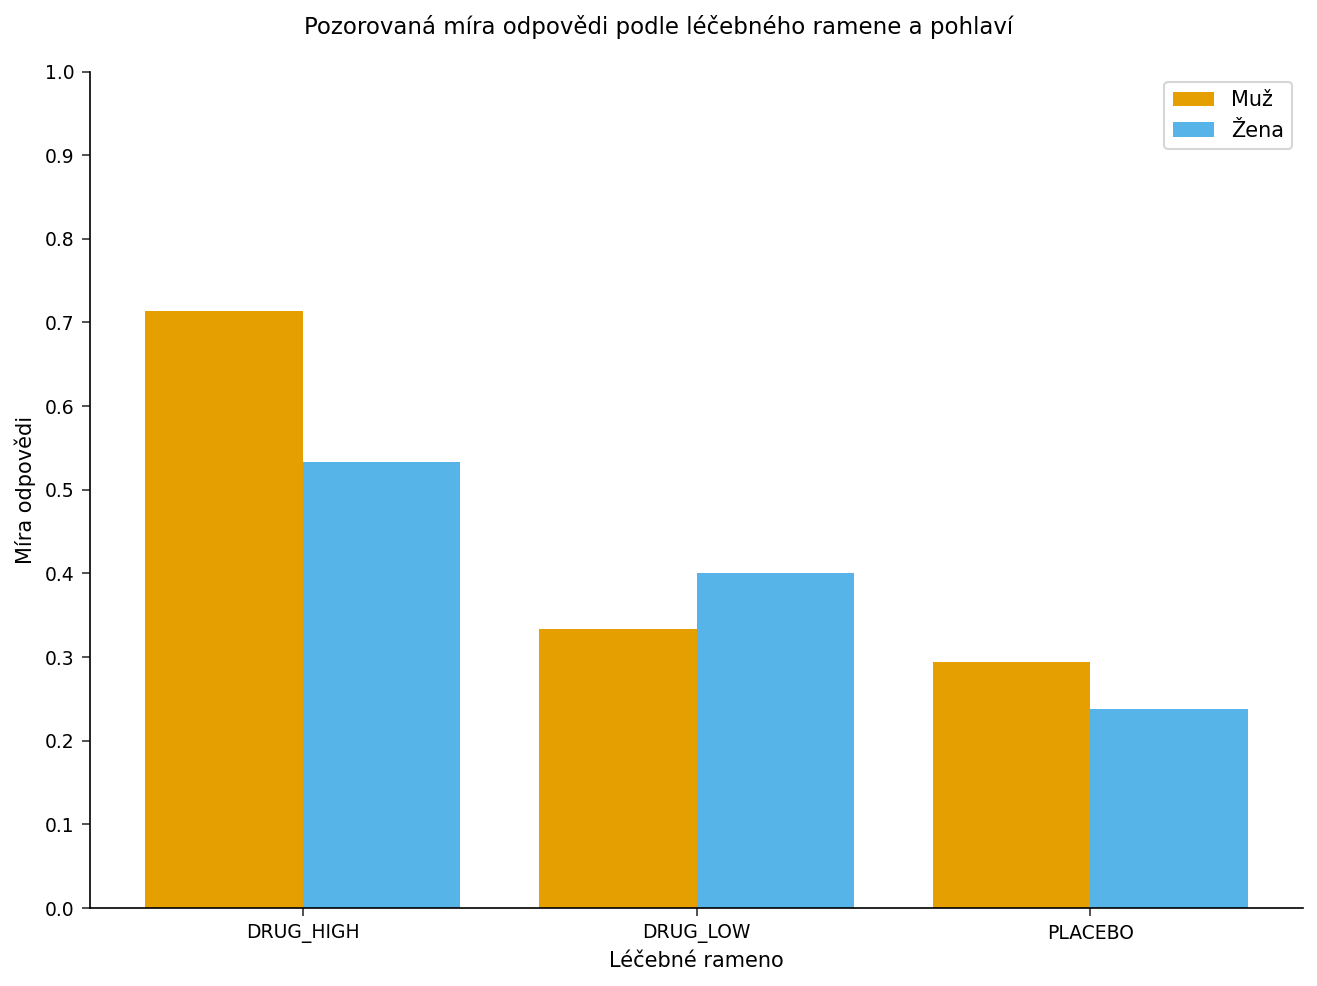

In [3]:
/* --------------------------------------------------------
   Míra odpovědi podle léčebného ramene a pohlaví
   -------------------------------------------------------- */
NÁZEV "Pozorovaná míra odpovědi podle léčebného ramene a pohlaví";
PROCEDURA SGPLOT data=work.trial_resp;
    VBAR treatment_arm / response=response stat=mean
        group=sex groupdisplay=cluster;
    YAXIS label="Míra odpovědi" values=(0 to 1 by 0.1);
    XAXIS label="Léčebné rameno";
SPUSTIT;

---

In [4]:
/* --------------------------------------------------------
   Logit model binární odpovědi metodou maximální
   věrohodnosti. Oba prediktory jsou kategoriální, takže
   CATMOD tvoří malou kontingenční tabulku (3 ramena x 3
   vrstvy závažnosti = 9 populací) a odhaduje logit odpovědi
   metodou ML. RESPONSE LOGITS volí logitovou funkci odpovědi.
   -------------------------------------------------------- */
NÁZEV "Logit ANOVA: Odpověď na léčbu podle ramene a vrstvy výchozí závažnosti";
PROCEDURA catmod data=work.trial_resp;
    response logits;
    MODEL response = treatment_arm severity_grp
        / freq prob pred=freq;
SPUSTIT;

                         Logit ANOVA: Odpověď na léčbu podle ramene a vrstvy výchozí závažnosti                         


The CATMOD Procedure

Response: Odpověď na léčbu

Response Profiles
Response   Odpověď na léčbu    
------------------------------
1          0                   
2          1                   

Population Profiles
Sample     Léčebné rameno  Skupina závažnosti
------------------------------------------
1          DRUG_LOW        Severe         
2          DRUG_HIGH       Moderate       
3          PLACEBO         Mild           
4          PLACEBO         Severe         
5          PLACEBO         Moderate       
6          DRUG_HIGH       Severe         
7          DRUG_HIGH       Mild           
8          DRUG_LOW        Moderate       
9          DRUG_LOW        Mild           

Maximum Likelihood Analysis of Variance
Source                  DF      Chi-Square Pr > ChiSq
-------------------------------------------------------
Intercept                1        


NOTE: Option TITLE changed to Logit ANOVA: Odpověď na léčbu podle ramene a vrstvy výchozí závažnosti.
NOTE: PROC CATMOD 

NOTE: PROC CATMOD using Python wrapper
NOTE: PROC CATMOD step completed.


In [5]:
/* --------------------------------------------------------
   Zachycení odhadů parametrů přes ODS OUTPUT pro následné
   vygenerování forest plotu.
   -------------------------------------------------------- */
ODS VÝSTUP parameterestimates=work.catmod_parms;

PROCEDURA catmod data=work.trial_resp;
    response logits;
    MODEL response = treatment_arm severity_grp;
SPUSTIT;

ODS VÝSTUP CLOSE;

                         Logit ANOVA: Odpověď na léčbu podle ramene a vrstvy výchozí závažnosti                         


The CATMOD Procedure

Response: Odpověď na léčbu

Response Profiles
Response   Odpověď na léčbu    
------------------------------
1          0                   
2          1                   

Population Profiles
Sample     Léčebné rameno  Skupina závažnosti
------------------------------------------
1          DRUG_LOW        Severe         
2          DRUG_HIGH       Moderate       
3          PLACEBO         Mild           
4          PLACEBO         Severe         
5          PLACEBO         Moderate       
6          DRUG_HIGH       Severe         
7          DRUG_HIGH       Mild           
8          DRUG_LOW        Moderate       
9          DRUG_LOW        Mild           

Maximum Likelihood Analysis of Variance
Source                  DF      Chi-Square Pr > ChiSq
-------------------------------------------------------
Intercept                1        


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> catmod_parms
NOTE: PROC CATMOD 

NOTE: PROC CATMOD using Python wrapper
NOTE: PROC CATMOD step completed.
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Prohlídka odhadů parametrů
   -------------------------------------------------------- */
NÁZEV "Odhady parametrů CATMOD pro model odpovědi na léčbu";
PROCEDURA TISK data=work.catmod_parms;
SPUSTIT;

                                  Odhady parametrů CATMOD pro model odpovědi na léčbu                                   


  Obs        PARAMETER  ESTIMATE  STDERR  CHISQUARE  PROBCHISQ
-----  ---------------  --------  ------  ---------  ---------
    1  Intercept_1          0.21    0.24      0.766     0.3815
    2  treatment_arm_1    0.1563  0.3076      0.258     0.6115
    3  treatment_arm_2   -0.9622  0.3242     8.8098      0.003
    4  severity_grp_1     -0.339  0.3384      1.004     0.3163
    5  severity_grp_2     0.5218  0.3165     2.7175     0.0993




NOTE: Option TITLE changed to Odhady parametrů CATMOD pro model odpovědi na léčbu.
NOTE: PROC PRINT data=work.catmod_parms

NOTE: PROC PRINT completed: 5 observations printed, 5 variables


---

### Interpretace

Všechny níže uvedené hodnoty jsou přečteny přímo ze spuštěného výstupu výše.

**Pozorované míry odpovědi (PROC FREQ).** Z 5,000 pacientů bylo 1,841 (36.8%)
respondérů. Míra odpovědi trvale rostla s dávkou: PLACEBO 406/1,714 (23.7%),
DRUG_LOW 607/1,637 (37.1%) a DRUG_HIGH 828/1,649 (50.2%). Po sloučení napříč rameny
odpověď rovněž rostla s výchozí závažností: Mírná 405/1,220 (33.2%), Střední 905/2,521
(35.9%) a Těžká 531/1,259 (42.2%).

**Analýza rozptylu metodou maximální věrohodnosti (PROC CATMOD).** CATMOD křížově
klasifikoval data do 9 populací (3 ramena x 3 strata závažnosti) a proložil logit odpovědi
metodou maximální věrohodnosti. Oba faktory byly vysoce významné: `treatment_arm`
(chí-kvadrát = 245.67, df = 2, p < 0.0001) a `severity_grp`
(chí-kvadrát = 24.04, df = 2, p < 0.0001). Reziduální statistika věrohodnostního poměru
(chí-kvadrát = 10.67, df = 4, p = 0.0306) naznačuje malou, ale zjistitelnou neshodu
proložení u aditivního modelu bez interakcí -- což je zde očekávané, protože proces
generující data umožňuje, aby se sklon závažnosti mírně lišil podle ramene.

**Odhady parametrů (zachycené pomocí `ODS OUTPUT`).** CATMOD používá kódování se součtem
rovným nule (efektové kódování) a proložená logitová funkce je logaritmus šance
*non-odpovědi* (response = 0) vzhledem k response = 1, takže záporný odhad označuje úroveň
s nadprůměrnou odpovědí. Intercept je 0.5520 (chí-kvadrát = 294.57), což odráží, že
non-respondéři celkově převažují nad respondéry. Efekt DRUG_HIGH je -0.5738
(chí-kvadrát = 188.77, p < 0.0001) -- výrazně pod celkovým průměrem, tj. nejlépe odpovídající
rameno -- zatímco efekt DRUG_LOW je -0.0350 (p = 0.4098), blízko celkovému průměru, přičemž
PLACEBO slouží jako kladná (nejhůře odpovídající) referenční úroveň. Pro závažnost je efekt
Těžká -0.2277 (chí-kvadrát = 23.68, p < 0.0001), což potvrzuje vyšší odpověď v nejzávažnějším
stratu, zatímco efekt Střední (0.0553, p = 0.1702) se od celkového průměru významně neliší.

**Závěr.** Aktivní léčba a vyšší výchozí závažnost každá nezávisle zvyšují pravděpodobnost
klinické odpovědi, přičemž největší efekt vykazuje rameno s vysokou dávkou. Tyto zachycené
odhady parametrů slouží jako vstup pro navazující export forest plotu.


---

In [7]:
/* --------------------------------------------------------
   Export odhadů parametrů pro vygenerování forest plotu
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.catmod_parms
    OUTFILE='treatment_response_catmod_parms.csv'
    DBMS=csv REPLACE;
SPUSTIT;


NOTE: PROC EXPORT data=work.catmod_parms outfile=treatment_response_catmod_parms.csv

NOTE: Exported 5 rows to treatment_response_catmod_parms.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Využívá <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>